In [1]:
# ============================================================
# Mean-Variance-Kurtosis Portfolio Optimization
# Benchmark: NIFTY 50
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import kurtosis

# =========================
# NIFTY STOCKS
# =========================
assets = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "INFY.NS",
    "ITC.NS",
    "LT.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS"
]

benchmark = "^NSEI"

# =========================
# DOWNLOAD STOCK DATA
# =========================
prices = yf.download(
    assets,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

benchmark_prices = yf.download(
    benchmark,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

# =========================
# DAILY RETURNS
# =========================
returns = prices.pct_change().dropna()

benchmark_returns = benchmark_prices.pct_change().dropna()

# =========================
# ANNUALIZED STATISTICS
# =========================
mean_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

num_assets = len(assets)

# =========================
# PORTFOLIO FUNCTIONS
# =========================
def portfolio_return(weights):
    return np.dot(weights, mean_returns)


def portfolio_variance(weights):
    return np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )


def portfolio_kurtosis(weights):
    portfolio_returns = returns.dot(weights)
    return kurtosis(
        portfolio_returns,
        fisher=False
    )

# =========================
# OBJECTIVE FUNCTION
# =========================
alpha = 1.0
beta = 3.0
gamma = 2.0

def objective(weights):

    ret = portfolio_return(weights)

    var = portfolio_variance(weights)

    kurt = portfolio_kurtosis(weights)

    utility = (
        alpha * ret
        - beta * var
        - gamma * kurt
    )

    return -utility

In [4]:
# ============================================================
# CONSTRAINTS
# ============================================================

constraints = (
    {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    },
)

bounds = tuple((0.05, 0.30) for _ in range(num_assets))

initial_weights = np.ones(num_assets) / num_assets

# ============================================================
# OPTIMIZATION
# ============================================================

result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

# ============================================================
# OPTIMIZED PORTFOLIO RETURNS
# ============================================================

portfolio_returns = returns.dot(optimal_weights)

# ============================================================
# PORTFOLIO PERFORMANCE
# ============================================================

risk_free_rate = 0.06

portfolio_return_annual = portfolio_returns.mean() * 252

portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

portfolio_sharpe = (
    portfolio_return_annual - risk_free_rate
) / portfolio_volatility

portfolio_kurt = kurtosis(
    portfolio_returns,
    fisher=False
)

# ============================================================
# BENCHMARK PERFORMANCE
# ============================================================

benchmark_returns = benchmark_prices.pct_change().dropna()

benchmark_return = benchmark_returns.mean() * 252

benchmark_volatility = benchmark_returns.std() * np.sqrt(252)

benchmark_sharpe = (
    benchmark_return - risk_free_rate
) / benchmark_volatility

benchmark_kurt = kurtosis(
    benchmark_returns,
    fisher=False
)

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Kurtosis"
    ],

    "MVK Portfolio": [
        portfolio_return_annual,
        portfolio_volatility,
        portfolio_sharpe,
        portfolio_kurt
    ],

    "NIFTY 50": [
        benchmark_return,
        benchmark_volatility,
        benchmark_sharpe,
        benchmark_kurt
    ]

})

# ============================================================
# PORTFOLIO WEIGHTS
# ============================================================

weights_df = pd.DataFrame({

    "Asset": assets,
    "Weight": np.round(optimal_weights, 4)

})

# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 65)
print("MEAN-VARIANCE-KURTOSIS vs NIFTY 50")
print("=" * 65)

print("\nOptimized Portfolio Weights")
print(weights_df)

print("\nPerformance Comparison")
print(comparison.round(4))

print("\nOptimization Success :", result.success)
print("Message :", result.message)

MEAN-VARIANCE-KURTOSIS vs NIFTY 50

Optimized Portfolio Weights
           Asset  Weight
0    RELIANCE.NS    0.05
1         TCS.NS    0.05
2    HDFCBANK.NS    0.05
3   ICICIBANK.NS    0.05
4        INFY.NS    0.05
5         ITC.NS    0.05
6          LT.NS    0.05
7        SBIN.NS    0.05
8  BHARTIARTL.NS    0.30
9  HINDUNILVR.NS    0.30

Performance Comparison
              Metric  MVK Portfolio                                 NIFTY 50
0      Annual Return         0.2089  Ticker
^NSEI    0.153717
dtype: float64
1  Annual Volatility         0.2012  Ticker
^NSEI    0.191151
dtype: float64
2       Sharpe Ratio         0.7400   Ticker
^NSEI    0.49028
dtype: float64
3           Kurtosis        15.3948                      [21.89330090595047]

Optimization Success : True
Message : Optimization terminated successfully




ADDITIONAL PERFORMANCE METRICS
Portfolio CAGR         : 0.2073
NIFTY CAGR             : 0.1446

Portfolio Max Drawdown : -0.3434
NIFTY Max Drawdown     : -0.3844


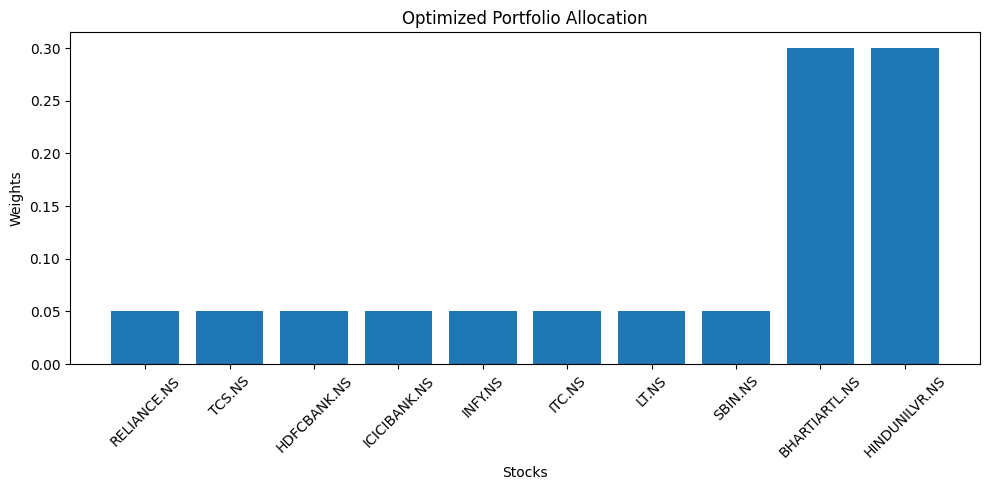

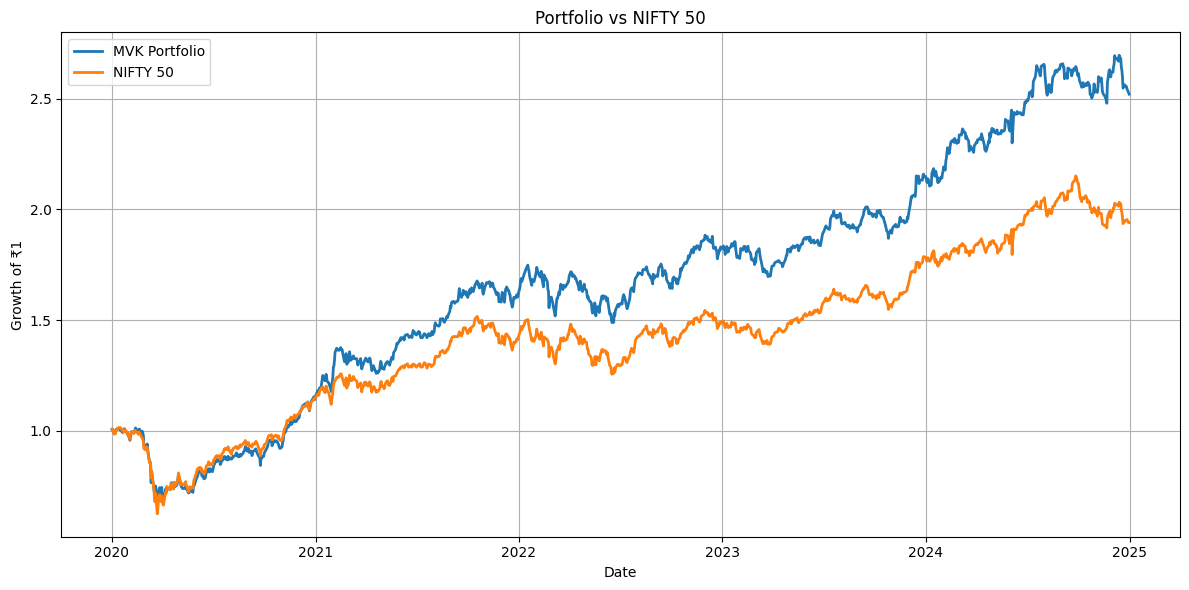


Files Saved Successfully
-------------------------
1. MVK_Portfolio_Weights.csv
2. Performance_Comparison.csv
3. Portfolio_Allocation.png
4. Portfolio_vs_NIFTY.png

Project Completed Successfully!


In [6]:
# ============================================================
# CUMULATIVE RETURNS
# ============================================================

portfolio_cumulative = (1 + portfolio_returns).cumprod()

benchmark_cumulative = (1 + benchmark_returns).cumprod()

# ============================================================
# CAGR
# ============================================================

years = len(portfolio_returns) / 252

portfolio_cagr = (
    portfolio_cumulative.iloc[-1] ** (1 / years)
) - 1

benchmark_cagr = (
    benchmark_cumulative.iloc[-1, 0] ** (1 / years)
) - 1

# ============================================================
# MAXIMUM DRAWDOWN
# ============================================================

portfolio_running_max = portfolio_cumulative.cummax()

portfolio_drawdown = (
    portfolio_cumulative - portfolio_running_max
) / portfolio_running_max

portfolio_max_drawdown = portfolio_drawdown.min()

benchmark_running_max = benchmark_cumulative.cummax()

benchmark_drawdown = (
    benchmark_cumulative - benchmark_running_max
) / benchmark_running_max

benchmark_max_drawdown = benchmark_drawdown.min().iloc[0]

# ============================================================
# ADDITIONAL METRICS
# ============================================================

print("\n")
print("=" * 65)
print("ADDITIONAL PERFORMANCE METRICS")
print("=" * 65)

print(f"Portfolio CAGR         : {portfolio_cagr:.4f}")
print(f"NIFTY CAGR             : {benchmark_cagr:.4f}")

print(f"\nPortfolio Max Drawdown : {portfolio_max_drawdown:.4f}")
print(f"NIFTY Max Drawdown     : {benchmark_max_drawdown:.4f}")

# ============================================================
# PORTFOLIO ALLOCATION
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(weights_df["Asset"], weights_df["Weight"])

plt.title("Optimized Portfolio Allocation")

plt.xlabel("Stocks")

plt.ylabel("Weights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("Portfolio_Allocation.png")

plt.show()

# ============================================================
# CUMULATIVE RETURNS COMPARISON
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    portfolio_cumulative,
    label="MVK Portfolio",
    linewidth=2
)

plt.plot(
    benchmark_cumulative.iloc[:, 0],
    label="NIFTY 50",
    linewidth=2
)

plt.title("Portfolio vs NIFTY 50")

plt.xlabel("Date")

plt.ylabel("Growth of ₹1")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("Portfolio_vs_NIFTY.png")

plt.show()

# ============================================================
# SAVE RESULTS
# ============================================================

weights_df.to_csv(
    "MVK_Portfolio_Weights.csv",
    index=False
)

comparison.to_csv(
    "Performance_Comparison.csv",
    index=False
)

print("\nFiles Saved Successfully")
print("-------------------------")
print("1. MVK_Portfolio_Weights.csv")
print("2. Performance_Comparison.csv")
print("3. Portfolio_Allocation.png")
print("4. Portfolio_vs_NIFTY.png")

print("\nProject Completed Successfully!")